# 初步探索性分析

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


--- Loading Data ---
Dataset Shape: (1225088, 7)


,uid,mid,time,forward_count,comment_count,like_count,content
0,d38e9bed5d98110dc2489d0d1cac3c2a,7d45833d9865727a88b960b0603c19f6,2015-02-23 17:41:29,0,0,0,丽江旅游(sz002033)#股票##炒股##财经##理财##投资#推荐包赢股，盈利对半分成...
1,fa13974743d3fe6ff40d21b872325e9e,8169f1d45051e08ef213bf1106b1225d,2015-02-14 12:49:58,0,0,0,#丁辰灵的红包#挣钱是一种能力，抢红包拼的是技术。我抢到了丁辰灵 和@阚洪岩 一起发出的现金...
2,da534fe87e7a52777bee5c30573ed5fd,68cd0258c31c2c525f94febea2d9523b,2015-03-31 13:58:06,0,0,0,淘宝网这些傻逼。。。气的劳资有火没地儿发~尼玛，你们都瞎了
3,e06a22b7e065e559a1f0bf7841a85c51,00b9f86b4915aedb7db943c54fd19d59,2015-06-11 20:39:57,0,4,3,看点不能说的，你们都懂[笑cry]
4,f9828598f9664d4e347ef2048ce17734,c7f6f66044c0c5a3330e2c5371be6824,2015-03-10 18:02:38,0,0,0,111多张



--- Data Types & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 1225088 entries, 0 to 1225087
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   uid            1225088 non-null  str  
 1   mid            1225088 non-null  str  
 2   time           1225088 non-null  str  
 3   forward_count  1225088 non-null  int64
 4   comment_count  1225088 non-null  int64
 5   like_count     1225088 non-null  int64
 6   content        1225085 non-null  str  
dtypes: int64(3), str(4)
memory usage: 65.4 MB
None

Missing Values:
uid              0
mid              0
time             0
forward_count    0
comment_count    0
like_count       0
content          3
dtype: int64

--- Basic Statistical Summary (Outlier Check) ---


,forward_count,comment_count,like_count
count,1.225088e+06,1.225088e+06,1.225088e+06
mean,3.540621e+00,1.257382e+00,2.217098e+00
std,8.528489e+01,1.933314e+01,4.126350e+01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,1.000000e+00
max,4.185000e+04,7.467000e+03,1.187100e+04


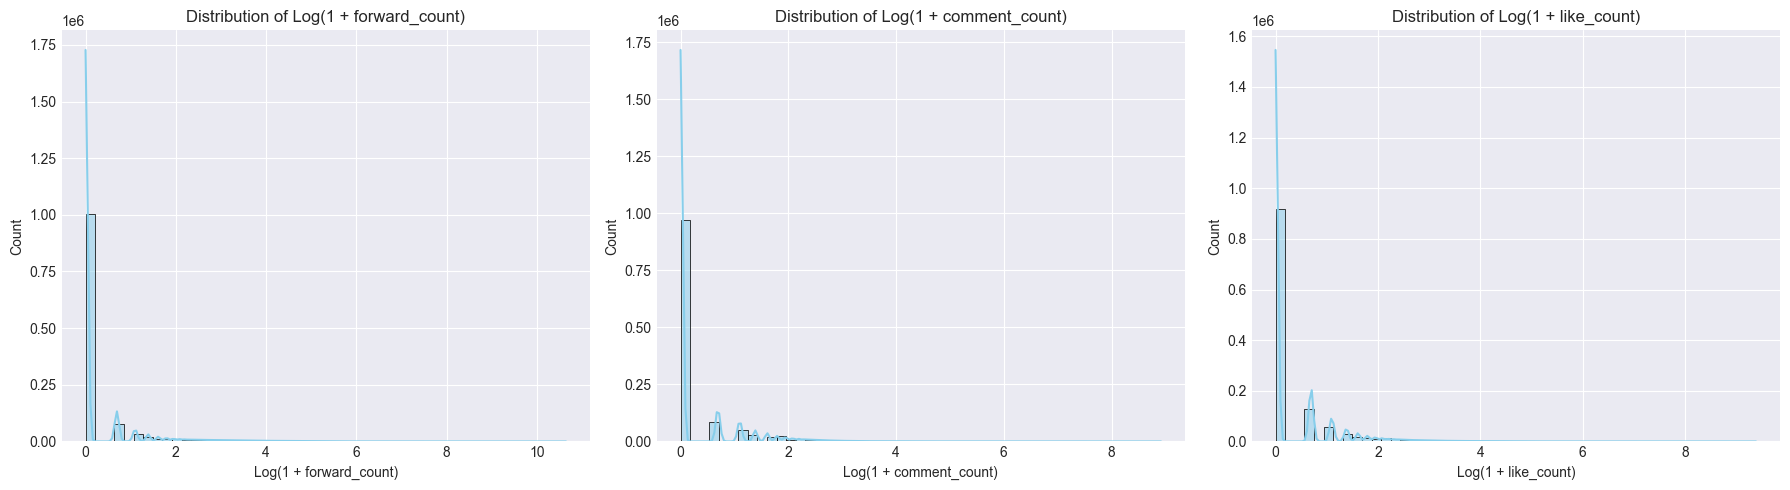

Percentage of posts with ZERO forward_count: 82.10%
Percentage of posts with ZERO comment_count: 79.34%
Percentage of posts with ZERO like_count: 74.89%

--- Time Pattern Analysis ---


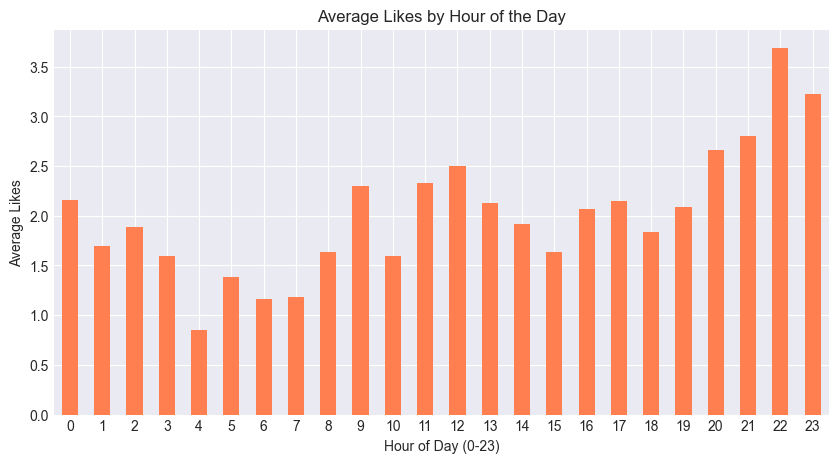

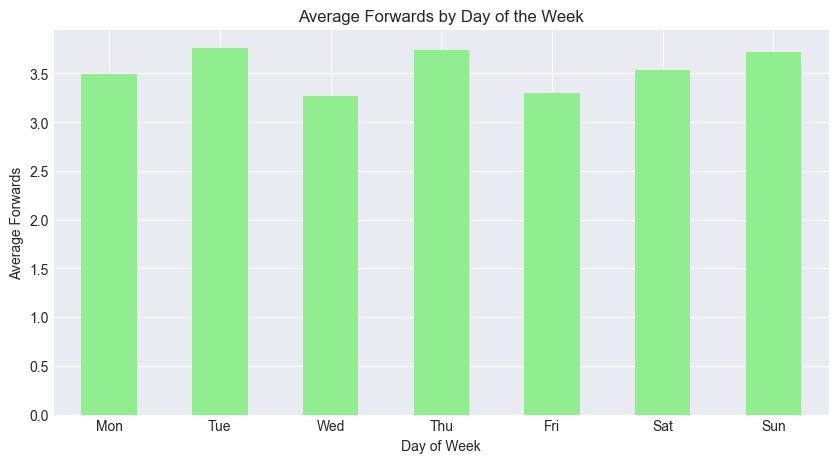


--- Content Length Analysis ---


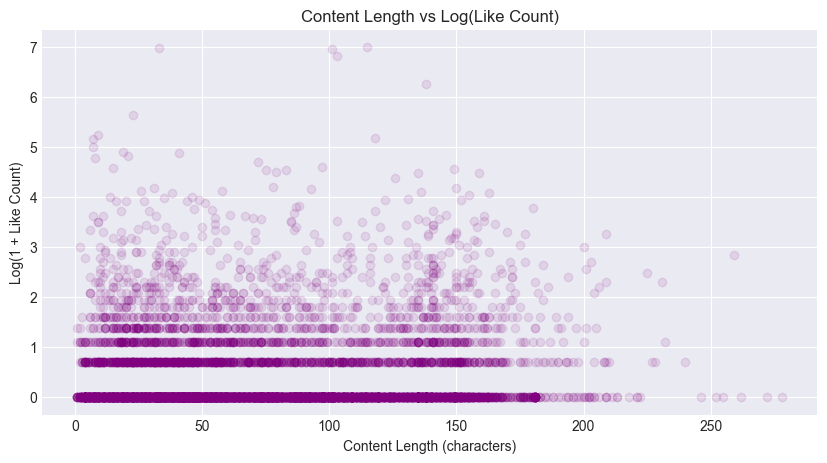

In [2]:

# Set plot style and ignore warnings for cleaner output
plt.style.use('seaborn-v0_8-darkgrid')
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. Load and inspect training data
# ---------------------------------------------------------
print("--- Loading Data ---")
# Adjust the file path and separator (usually '\t' for this competition)
# Assuming columns are: uid, mid, time, forward_count, comment_count, like_count, content
columns = ['uid', 'mid', 'time', 'forward_count', 'comment_count', 'like_count', 'content']

# Use a sample parameter (nrows) if the dataset is too large for your RAM initially
df = pd.read_csv(r'dataset/weibo_train_data.txt', sep='\t', header=None, names=columns)

print(f"Dataset Shape: {df.shape}")
display(df.head())

# ---------------------------------------------------------
# 2. Check data types, missing values, and outliers
# ---------------------------------------------------------
print("\n--- Data Types & Missing Values ---")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

print("\n--- Basic Statistical Summary (Outlier Check) ---")
# This will show you the max values, which are likely massive (viral posts)
display(df[['forward_count', 'comment_count', 'like_count']].describe())

# ---------------------------------------------------------
# 3. Analyze distribution of target variables (Heavy-tailed)
# ---------------------------------------------------------
# Because social media data is heavy-tailed, plotting raw data will look like a single spike.
# We use np.log1p (log(1 + x)) to visualize the distribution properly.

targets = ['forward_count', 'comment_count', 'like_count']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(targets):
    # Log transformation for visualization
    log_data = np.log1p(df[col])
    sns.histplot(log_data, bins=50, ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(f'Distribution of Log(1 + {col})')
    axes[i].set_xlabel(f'Log(1 + {col})')
    
plt.tight_layout()
plt.show()

# Calculate percentage of zero interactions (Very important for modeling!)
for col in targets:
    zero_pct = (df[col] == 0).mean() * 100
    print(f"Percentage of posts with ZERO {col}: {zero_pct:.2f}%")

# ---------------------------------------------------------
# 4. Explore posting time patterns
# ---------------------------------------------------------
print("\n--- Time Pattern Analysis ---")
# Convert 'time' to datetime object
df['time'] = pd.to_datetime(df['time'])

# Extract time features
df['month'] = df['time'].dt.month
df['day_of_week'] = df['time'].dt.dayofweek # 0=Monday, 6=Sunday
df['hour'] = df['time'].dt.hour

# Plotting average likes by hour of the day
plt.figure(figsize=(10, 5))
df.groupby('hour')['like_count'].mean().plot(kind='bar', color='coral')
plt.title('Average Likes by Hour of the Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Likes')
plt.xticks(rotation=0)
plt.show()

# Plotting average forwards by day of the week
plt.figure(figsize=(10, 5))
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df.groupby('day_of_week')['forward_count'].mean().plot(kind='bar', color='lightgreen')
plt.title('Average Forwards by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Forwards')
plt.xticks(ticks=range(7), labels=days, rotation=0)
plt.show()

# ---------------------------------------------------------
# 5. Analyze post content (Length basics)
# ---------------------------------------------------------
print("\n--- Content Length Analysis ---")
# Fill missing content with empty string just in case
df['content'] = df['content'].fillna('')

# Calculate length of the text
df['content_length'] = df['content'].apply(len)

# See if longer posts get more likes (using scatter plot with log-scale targets)
plt.figure(figsize=(10, 5))
# Sampling 10,000 points so the plot doesn't take forever to render
sample_df = df.sample(n=10000, random_state=42) 
plt.scatter(sample_df['content_length'], np.log1p(sample_df['like_count']), alpha=0.1, color='purple')
plt.title('Content Length vs Log(Like Count)')
plt.xlabel('Content Length (characters)')
plt.ylabel('Log(1 + Like Count)')
plt.show()

# 处理数据 and 特征提取

In [ ]:
import pickle
import os
from data_process import preprocess_data
from feature_eng import create_features


TRAIN_DATA_PATH = 'dataset/weibo_train_data.txt'
PREDICT_DATA_PATH = 'dataset/weibo_predict_data.txt'
TRAIN_PKL_PATH = 'dataset/weibo_train_features.pkl'
PREDICT_PKL_PATH = 'dataset/weibo_predict_features.pkl'
SUBMISSION_PATH = 'submission/submission_latest.txt'

if os.path.exists(TRAIN_PKL_PATH) and os.path.exists(PREDICT_PKL_PATH):
    print("Loading pre-engineered features from pickle files...")
    with open(TRAIN_PKL_PATH, 'rb') as f:
        df_train_final = pickle.load(f)
    with open(PREDICT_PKL_PATH, 'rb') as f:
        df_test_final = pickle.load(f)
else:
    print("Generating features from scratch...")
    # Load raw data
    print("Loading raw data...")
    df_train = pd.read_csv(TRAIN_DATA_PATH, sep='\t', header=None, 
                               names=['uid', 'mid', 'time', 'forward_count', 'comment_count', 'like_count', 'content'])
    df_test = pd.read_csv(PREDICT_DATA_PATH, sep='\t', header=None, 
                              names=['uid', 'mid', 'time', 'content'])
        
    # Preprocess
    df_train_clean = preprocess_data(df_train, is_train=True)
    df_test_clean = preprocess_data(df_test, is_train=False)
        
    # Feature Engineering
    df_train_final, df_test_final = create_features(df_train_clean, df_test_clean)
        
    # Save for next time
    print("Saving features to pickle files...")
    with open(TRAIN_PKL_PATH, 'wb') as f:
            pickle.dump(df_train_final, f)
    with open(PREDICT_PKL_PATH, 'wb') as f:
            pickle.dump(df_test_final, f)

print(f"Final Train Shape: {df_train_final.shape}")
print(f"Final Test Shape: {df_test_final.shape}")

Loading pre-engineered features from pickle files...
Final Train Shape: (1225088, 45)
Final Test Shape: (177923, 45)


# 训练基线模型

In [6]:
# 1. Get baseline (just to see how simple rules look)
from model import baseline_model_predict, get_time_split, train_lgbm_models, train_xgboost_and_ensemble


df_baseline_preds = baseline_model_predict(df_test_final)

# 2. Split data chronologically
train_set, valid_set = get_time_split(df_train_final)

# 3. Train LightGBM models
lgbm_models, lgbm_val_preds, lgbm_test_preds = train_lgbm_models(train_set, valid_set, df_test_final)

# 4. Train XGBoost and fuse them together!
final_test_predictions = train_xgboost_and_ensemble(train_set, valid_set, df_test_final, lgbm_test_preds)

--- Running Baseline Model ---
--- Creating Time-Based Split ---
Training set shape (Feb-Jun): (1040874, 45)
Validation set shape (Jul): (184214, 45)

--- Training LightGBM Models ---
Number of features used: 32

>>> Training for target: forward_count_log <<<
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4930
[LightGBM] [Info] Number of data points in the train set: 1040874, number of used features: 32
[LightGBM] [Info] Start training from score 0.296423
Training until validation scores don't improve for 50 rounds
[100]	training's l1: 0.237377	valid_1's l1: 0.261724
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

# 计算分数

In [7]:
from calculate_score import calculate_weibo_score

# 1. 获取真实值：直接使用原始计数列
real_data = valid_set[['forward_count', 'comment_count', 'like_count']]

# 2. 获取预测值：
# 假设 lgbm_val_preds 内部已经做了 np.expm1 还原（根据 molde.py 的逻辑）
# 我们只需要重命名列名，让它符合评分函数的要求
pred_data = lgbm_val_preds[['forward_count_log', 'comment_count_log', 'like_count_log']].copy()
pred_data.columns = ['forward_count', 'comment_count', 'like_count']

# 3. 计算得分
score = calculate_weibo_score(real_data, pred_data)


  总分: 30.9287%
  整体命中率(precision>0.8): 82.53%
  高互动样本命中率: 8.15% (9157条)
  precision_i 均值: 0.8719, 中位数: 0.9492


In [8]:
print("=== 开始本地验证集评估 ===")

# 1. 提取真实的验证集目标值 (正确：使用原始计数列)
real_valid_data = valid_set[['forward_count', 'comment_count', 'like_count']]

# 2. 评估 Baseline 模型
# Baseline 函数内部返回的已经是 'forward_count' 等正确列名，所以这里不用改
baseline_val_preds = baseline_model_predict(valid_set)
print("\n[Baseline] 基于用户历史平均值的得分:")
baseline_score = calculate_weibo_score(real_valid_data, baseline_val_preds)

# 3. 评估 LightGBM 模型
print("\n[LightGBM] 机器学习模型的得分:")
# --- 修改点：在评估前，通过 rename 将列名中的 '_log' 去掉，以匹配评分函数 ---
lgbm_val_preds_renamed = lgbm_val_preds.rename(columns={
    'forward_count_log': 'forward_count',
    'comment_count_log': 'comment_count',
    'like_count_log': 'like_count'
})
# 传入重命名后的预测结果
lgbm_score = calculate_weibo_score(real_valid_data, lgbm_val_preds_renamed)

print(f"\n🚀 模型提升: {(lgbm_score - baseline_score) * 100:.4f}%")


=== 开始本地验证集评估 ===
--- Running Baseline Model ---

[Baseline] 基于用户历史平均值的得分:
  总分: 27.5265%
  整体命中率(precision>0.8): 73.40%
  高互动样本命中率: 8.71% (9157条)
  precision_i 均值: 0.6529, 中位数: 0.9375

[LightGBM] 机器学习模型的得分:
  总分: 30.9287%
  整体命中率(precision>0.8): 82.53%
  高互动样本命中率: 8.15% (9157条)
  precision_i 均值: 0.8719, 中位数: 0.9492

🚀 模型提升: 3.4022%


# 生成提交结果

In [ ]:
from submission import generate_submission

# 1. 重命名列名：将模型输出的带有 _log 后缀的列名 对齐到 比赛要求的列名
final_test_predictions_renamed = final_test_predictions.rename(columns={
    'forward_count_log': 'forward_count',
    'comment_count_log': 'comment_count',
    'like_count_log': 'like_count'
})

# 2. 生成提交文件
generate_submission(final_test_predictions_renamed, SUBMISSION_PATH)


--- 正在生成提交文件: submission_2.0.txt ---
✅ 提交文件生成完毕！
文件头部预览：
'7511e346911dd7d1e38f11485abb25c5\ta8d6a804eeacd2f67f8bbbf9457f1708\t0,0,0\n'
'1335da4774891627216cd051b670e36f\t0c0603e915d53c44fb2612532e8e85b5\t0,0,0\n'
'c66937472392d2b6cb1ee57091304b5e\t458a1d71d37da156ae26e32a5fd5fbe2\t0,0,0\n'
'0dc5b1896698c475e7bb191ccfd7cc45\t96af081a8c3401891940527c75cb3c62\t0,2,2\n'
'fc8169f8879db1bf0026a9a4bfdfc1e4\t1cf853a96e965197490c3af0530e9730\t0,0,0\n'


2.0 --> 30.9287%